# Product Intelligence Notebook
**E-commerce Marketplaces Analysis**

*Author: Sitt Min Thar 

Analysis of 1,000 products across 5 marketplaces (Amazon, Noon, AliExpress, Jumia, eBay) spanning 10 categories

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Load the dataset
df = pd.read_csv('ecommerce_dataset.csv')

In [3]:
# Initial exploration
print(f"Dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"Currencies: {df['currency'].unique()}")
print(f"Sources: {df['source'].unique()}")
print(f"Categories: {df['category'].unique()}")

Dataset shape: (1000, 21)
Columns: ['product_id', 'external_id', 'title', 'brand', 'category', 'subcategory', 'url', 'source', 'price_current', 'price_original', 'currency', 'discount_pct', 'has_discount', 'rating_score', 'reviews_count', 'availability', 'description', 'images_count', 'first_image', 'tags', 'scraped_at']
Currencies: <StringArray>
['USD', 'AED', 'EGP']
Length: 3, dtype: str
Sources: <StringArray>
['amazon', 'noon', 'aliexpress', 'jumia', 'ebay']
Length: 5, dtype: str
Categories: <StringArray>
['Electronics',     'Fashion',        'Food',        'Home',      'Beauty',
  'Automotive',      'Sports',      'Garden',       'Books',        'Toys']
Length: 10, dtype: str


In [4]:
# Currency conversion function
def convert_to_usd(price, currency):
    if currency == 'USD':
        return price
    elif currency == 'AED':
        return price * 0.27
    elif currency == 'EGP':
        return price * 0.020
    else:
        return price

# Apply currency conversion
df['price_current_usd'] = df.apply(lambda x: convert_to_usd(x['price_current'], x['currency']), axis=1)
df['price_original_usd'] = df.apply(lambda x: convert_to_usd(x['price_original'], x['currency']), axis=1)

## Page 1 — Watchlist (Top 20 products to monitor)

In [6]:
# Calculate product score
df['score'] = (
    (df['rating_score'] / 5) * 30 + 
    (np.minimum(df['reviews_count'], 500) / 500) * 25 + 
    (df['discount_pct'] / 31) * 20 + 
    (df['availability'] == "in_stock").astype(int) * 15 + 
    (np.minimum(df['images_count'], 10) / 10) * 10
).fillna(0)

# Create watchlist
watchlist = df.copy()
watchlist['truncated_title'] = watchlist['title'].apply(lambda x: x[:60] + '...' if len(x) > 60 else x)
top_20 = watchlist.nlargest(20, 'score')[[
    'product_id', 'truncated_title', 'brand', 'source', 'price_current_usd', 'score', 'rating_score', 'reviews_count', 'discount_pct', 'availability', 'images_count'
]]

# Add reason for inclusion
reasons = []
for idx, row in top_20.iterrows():
    reasons.append(
        f"High rated ({row.rating_score:.1f}) with {row.reviews_count} reviews, {row.discount_pct:.1f}% discount"
        if row.discount_pct > 0 else
        f"High rated ({row.rating_score:.1f}) with {row.reviews_count} reviews, currently in stock"
    )

top_20['reason'] = reasons
top_20 = top_20.reset_index(drop=True)
top_20.index = top_20.index + 1

# Display watchlist
print("Top 20 Products to Monitor:")
watchlist_display = top_20[['truncated_title', 'brand', 'source', 'price_current_usd', 'score', 'reason']].copy()
watchlist_display.columns = ['Title', 'Brand', 'Source', 'Price (USD)', 'Score', 'Why it made the list']
print(watchlist_display.to_string(index_names=False))

Top 20 Products to Monitor:
                                       Title         Brand      Source  Price (USD)      Score                                Why it made the list
1                    Reebok Water Bottle Max        Reebok        noon     781.8255  90.419355   High rated (5.0) with 940 reviews, 30.1% discount
2                    Kellogg's Olive Oil Max     Kellogg's        ebay    1044.1300  88.896774   High rated (4.8) with 851 reviews, 29.6% discount
3                          Asus Earbuds 2024          Asus  aliexpress      60.6000  87.141935   High rated (4.4) with 674 reviews, 30.6% discount
4                    Lay's Multivitamin Lite         Lay's  aliexpress     329.9400  86.200000   High rated (4.2) with 526 reviews, 31.0% discount
5                             Braun Rug Plus         Braun       jumia     106.2332  84.529032   High rated (4.9) with 659 reviews, 21.9% discount
6   Random House Lightweight Masterclass Pro        Random      amazon    1618.4700  84.41

## Page 2 — Category Spotlights

In [7]:
# Get unique categories
categories = df['category'].unique()

for cat in categories:
    cat_df = df[df['category'] == cat]
    
    # Top product in category
    top_product = cat_df.loc[cat_df['score'].idxmax()] if not cat_df.empty else None
    
    # Price range
    min_price = cat_df['price_current_usd'].min()
    max_price = cat_df['price_current_usd'].max()
    
    # Average rating and review count
    avg_rating = cat_df['rating_score'].mean()
    avg_reviews = cat_df['reviews_count'].mean()
    
    # Most common availability status
    most_common_availability = cat_df['availability'].mode().iloc[0] if not cat_df['availability'].mode().empty else 'Unknown'
    
    print(f"\n### {cat} Category Mini-Brief")
    if top_product is not None:
        print(f"- Top Product: {top_product['title'][:50]}... (Score: {top_product['score']:.2f})")
    print(f"- Price Range: ${min_price:.2f} - ${max_price:.2f}")
    print(f"- Average Rating: {avg_rating:.2f}, Average Reviews: {avg_reviews:.0f}")
    print(f"- Most Common Availability: {most_common_availability}")
    
    # Generate recommendation
    if most_common_availability == 'limited':
        recommendation = f"Stock up on limited-availability items in {cat} before price spikes"
    elif avg_rating > 4.0:
        recommendation = f"Focus marketing efforts on high-rated {cat} items to boost sales"
    elif min_price < 20:
        recommendation = f"Promote affordable {cat} options as impulse buys"
    else:
        recommendation = f"Analyze pricing strategy for {cat} to improve competitiveness"
    
    print(f"- Recommendation: {recommendation}")


### Electronics Category Mini-Brief
- Top Product: Asus Earbuds 2024... (Score: 87.14)
- Price Range: $10.57 - $2997.17
- Average Rating: 3.71, Average Reviews: 263
- Most Common Availability: in_stock
- Recommendation: Promote affordable Electronics options as impulse buys

### Fashion Category Mini-Brief
- Top Product: Ralph Lauren Pro Hoodie... (Score: 83.45)
- Price Range: $1.22 - $2893.01
- Average Rating: 3.77, Average Reviews: 313
- Most Common Availability: in_stock
- Recommendation: Promote affordable Fashion options as impulse buys

### Food Category Mini-Brief
- Top Product: Kellogg's Olive Oil Max... (Score: 88.90)
- Price Range: $7.56 - $2928.91
- Average Rating: 3.81, Average Reviews: 272
- Most Common Availability: in_stock
- Recommendation: Promote affordable Food options as impulse buys

### Home Category Mini-Brief
- Top Product: Braun Rug Plus... (Score: 84.53)
- Price Range: $14.73 - $2928.38
- Average Rating: 3.76, Average Reviews: 235
- Most Common Availability: 

## Page 3 — Deal Tracker

In [8]:
# Filter discounted products with good ratings and reviews
deals_df = df[(df['has_discount'] == True) & 
              (df['rating_score'] > 3.5) & 
              (df['reviews_count'] > 50)].copy()

# Sort by discount percentage
best_deals = deals_df.nlargest(15, 'discount_pct')[[
    'title', 'price_original_usd', 'price_current_usd', 'discount_pct', 'source', 'rating_score', 'reviews_count'
]]

# Add deal quality label
def get_deal_label(discount):
    if discount >= 24:
        return 'Exceptional'
    elif discount >= 17:
        return 'Strong'
    else:
        return 'Good'

best_deals['deal_quality'] = best_deals['discount_pct'].apply(get_deal_label)
best_deals = best_deals.reset_index(drop=True)
best_deals.index = best_deals.index + 1

print("Top 15 Best Deals:")
deals_display = best_deals[[
    'title', 'price_original_usd', 'price_current_usd', 'discount_pct', 'source', 'rating_score', 'deal_quality'
]].copy()
deals_display.columns = [
    'Product Title', 'Original Price', 'Current Price', 'Discount %', 'Source', 'Rating', 'Deal Quality'
]
print(deals_display.round(2).to_string(index_names=False))

Top 15 Best Deals:
                               Product Title  Original Price  Current Price  Discount %      Source  Rating Deal Quality
1               Reebok Resistance Bands 2024         1641.68        1132.19        31.0        noon     3.6  Exceptional
2                    Lay's Multivitamin Lite          478.41         329.94        31.0  aliexpress     4.2  Exceptional
3                          Asus Earbuds 2024           87.26          60.60        30.6  aliexpress     4.4  Exceptional
4                 Mobil Wireless Tool Kit v2         1282.13         890.37        30.6       jumia     4.6  Exceptional
5   Random House Lightweight Masterclass Pro         2314.41        1618.47        30.1      amazon     4.0  Exceptional
6                    Reebok Water Bottle Max         1118.01         781.83        30.1        noon     5.0  Exceptional
7                            Philips Pro Rug          816.70         575.14        29.6      amazon     4.2  Exceptional
8            

## Page 4 — Brand Catalogue

In [9]:
# Filter brands with 3+ products
brand_counts = df['brand'].value_counts()
brands_with_3plus = brand_counts[brand_counts >= 3].index
filtered_brands_df = df[df['brand'].isin(brands_with_3plus)]

# Calculate metrics per brand
brand_metrics = filtered_brands_df.groupby('brand').agg({
    'product_id': 'count',
    'price_current_usd': 'mean',
    'rating_score': 'mean',
    'reviews_count': 'mean',
    'category': lambda x: x.mode().iloc[0] if not x.mode().empty else 'Unknown',
    'source': lambda x: x.mode().iloc[0] if not x.mode().empty else 'Unknown'
}).round(2)

# Rename columns
brand_metrics.columns = [
    'Product Count', 'Avg Price (USD)', 'Avg Rating', 'Avg Reviews', 'Primary Category', 'Primary Marketplace'
]

# Determine brand tier
def get_brand_tier(row):
    if row['Avg Price (USD)'] > 150 and row['Avg Rating'] > 4:
        return 'Premium'
    elif row['Avg Price (USD)'] < 50:
        return 'Value'
    else:
        return 'Standard'

brand_metrics['Brand Tier'] = brand_metrics.apply(get_brand_tier, axis=1)

print("Brand Catalogue (Brands with 3+ products):")
print(brand_metrics.to_string())

Brand Catalogue (Brands with 3+ products):
               Product Count  Avg Price (USD)  Avg Rating  Avg Reviews Primary Category Primary Marketplace Brand Tier
brand                                                                                                                 
3M                         5           691.96        3.44       167.20       Automotive          aliexpress   Standard
Acer                      11           452.84        3.48       233.27      Electronics               jumia   Standard
Adidas                    39           841.98        3.90       216.51           Sports               jumia   Standard
Apple                      8           924.62        3.73       371.50      Electronics               jumia   Standard
Asus                      12           606.77        4.02       255.08      Electronics               jumia    Premium
Barbie                    12           956.32        3.75       329.92             Toys                noon   Standard
Black

## Page 5 — Risk Register

In [10]:
# Identify risky products
risk_conditions = []

# Condition 1: Out of stock AND reviews_count > 200 (high-demand stockout)
high_demand_stockouts = df[(df['availability'] == 'out_of_stock') & (df['reviews_count'] > 200)].copy()
high_demand_stockouts['flag_type'] = 'High-demand stockout'
high_demand_stockouts['recommended_action'] = 'Restock immediately - high demand product out of inventory'

# Condition 2: rating_score < 3.0 AND reviews_count > 100 (confirmed poor performer)
poor_performers = df[(df['rating_score'] < 3.0) & (df['reviews_count'] > 100)].copy()
poor_performers['flag_type'] = 'Confirmed poor performer'
poor_performers['recommended_action'] = 'Consider removing from catalog or negotiating improvements with supplier'

# Condition 3: discount_pct > 28% AND rating_score < 3.5 (suspicious deep discount)
suspicious_discounts = df[(df['discount_pct'] > 28) & (df['rating_score'] < 3.5)].copy()
suspicious_discounts['flag_type'] = 'Suspicious deep discount'
suspicious_discounts['recommended_action'] = 'Investigate product quality or authenticity'

# Condition 4: images_count == 0 (unlisted or broken listing)
no_images = df[df['images_count'] == 0].copy()
no_images['flag_type'] = 'Missing product images'
no_images['recommended_action'] = 'Add product images to improve conversion rates'

# Combine all risky products
all_risky_products = pd.concat([high_demand_stockouts, poor_performers, suspicious_discounts, no_images])

if not all_risky_products.empty:
    risk_register = all_risky_products[['title', 'flag_type', 'recommended_action']].copy()
    risk_register = risk_register.reset_index(drop=True)
    risk_register.index = risk_register.index + 1
    
    print("Risk Register:")
    print(risk_register.to_string(index_names=False))
else:
    print("No risky products identified based on the criteria.")

Risk Register:
                                                    title                 flag_type                                                        recommended_action
1                             Adidas Portable Hoodie Plus      High-demand stockout                Restock immediately - high demand product out of inventory
2                               Calvin Klein Sneakers Pro      High-demand stockout                Restock immediately - high demand product out of inventory
3                             Mobil Deluxe Car Charger v2      High-demand stockout                Restock immediately - high demand product out of inventory
4                            Fenty Beauty Conditioner Max      High-demand stockout                Restock immediately - high demand product out of inventory
5                                     Dell Smartwatch Pro      High-demand stockout                Restock immediately - high demand product out of inventory
6                              Kellog

## Page 6 — Tags Intelligence

In [11]:
# Parse tags and analyze
from collections import Counter
import re

# Split tags and flatten into a single list
all_tags = []
for tags_str in df['tags'].dropna():
    if isinstance(tags_str, str):
        # Split by common delimiters
        tags_list = re.split(r'[;,|\s]+', tags_str)
        # Remove empty strings and strip whitespace
        tags_list = [tag.strip() for tag in tags_list if tag.strip()]
        all_tags.extend(tags_list)

# Count top 30 most frequent tags
top_30_tags = Counter(all_tags).most_common(30)
top_30_tag_names = [tag[0] for tag in top_30_tags]

print("Top 30 Most Frequent Tags:")
for i, (tag, count) in enumerate(top_30_tags, 1):
    print(f"{i:2d}. {tag:<20} ({count} occurrences)")

# Analyze correlation with ratings
tag_rating_corr = {}
tag_out_of_stock_corr = {}
tag_premium_corr = {}

for tag in top_30_tag_names:
    # Create a boolean mask for products with this tag
    mask = df['tags'].str.contains(tag, case=False, na=False)
    
    # Calculate average rating for products with this tag
    avg_rating = df[mask]['rating_score'].mean() if mask.any() else 0
    tag_rating_corr[tag] = avg_rating
    
    # Calculate percentage of out-of-stock items with this tag
    out_of_stock_pct = df[mask]['availability'].eq('out_of_stock').mean() if mask.any() else 0
    tag_out_of_stock_corr[tag] = out_of_stock_pct
    
    # Calculate average price for products with this tag
    avg_price = df[mask]['price_current_usd'].mean() if mask.any() else 0
    tag_premium_corr[tag] = avg_price

# Find tags with highest correlation to high ratings
high_rating_tags = sorted(tag_rating_corr.items(), key=lambda x: x[1], reverse=True)[:10]
print(f"\nTop 10 Tags Correlated with Higher Ratings:")
for tag, rating in high_rating_tags:
    print(f"- {tag}: Avg Rating {rating:.2f}")

# Find tags with highest correlation to out-of-stock items
out_of_stock_tags = sorted(tag_out_of_stock_corr.items(), key=lambda x: x[1], reverse=True)[:10]
print(f"\nTop 10 Tags on Out-of-Stock Items:")
for tag, pct in out_of_stock_tags:
    print(f"- {tag}: {pct:.2%} out of stock")

# Find tags with highest correlation to premium pricing
premium_tags = sorted(tag_premium_corr.items(), key=lambda x: x[1], reverse=True)[:10]
print(f"\nTop 10 Tags Associated with Premium Pricing:")
for tag, price in premium_tags:
    print(f"- {tag}: Avg Price ${price:.2f}")

Top 30 Most Frequent Tags:
 1. amazon               (200 occurrences)
 2. noon                 (200 occurrences)
 3. aliexpress           (200 occurrences)
 4. jumia                (200 occurrences)
 5. ebay                 (200 occurrences)
 6. beauty               (135 occurrences)
 7. sports               (127 occurrences)
 8. food                 (121 occurrences)
 9. home                 (120 occurrences)
10. fashion              (115 occurrences)
11. electronics          (113 occurrences)
12. toys                 (80 occurrences)
13. automotive           (78 occurrences)
14. garden               (57 occurrences)
15. books                (54 occurrences)

Top 10 Tags Correlated with Higher Ratings:
- beauty: Avg Rating 3.85
- sports: Avg Rating 3.84
- amazon: Avg Rating 3.84
- food: Avg Rating 3.81
- aliexpress: Avg Rating 3.78
- noon: Avg Rating 3.78
- fashion: Avg Rating 3.77
- home: Avg Rating 3.76
- books: Avg Rating 3.72
- electronics: Avg Rating 3.71

Top 10 Tags on Out-of-S

## Page 7 — Visualizations

In [13]:
# --- Chart 0: Setup (imports + shared config) ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

def normalize_to_usd(price, currency):
    """Convert price to USD based on currency"""
    conversion_rates = {'AED': 0.27, 'EGP': 0.020, 'USD': 1.0}
    return price * conversion_rates.get(currency, 1.0)  # Default to 1.0 if currency not in dict

# Define color dictionaries
source_colors = {"amazon": "#FF9900", "noon": "#0099CC", "aliexpress": "#FF4747", 
                 "jumia": "#3BB77E", "ebay": "#0064D2"}
category_colors = sns.color_palette("tab10")

print("Setup complete: Libraries imported and configurations defined")

Setup complete: Libraries imported and configurations defined


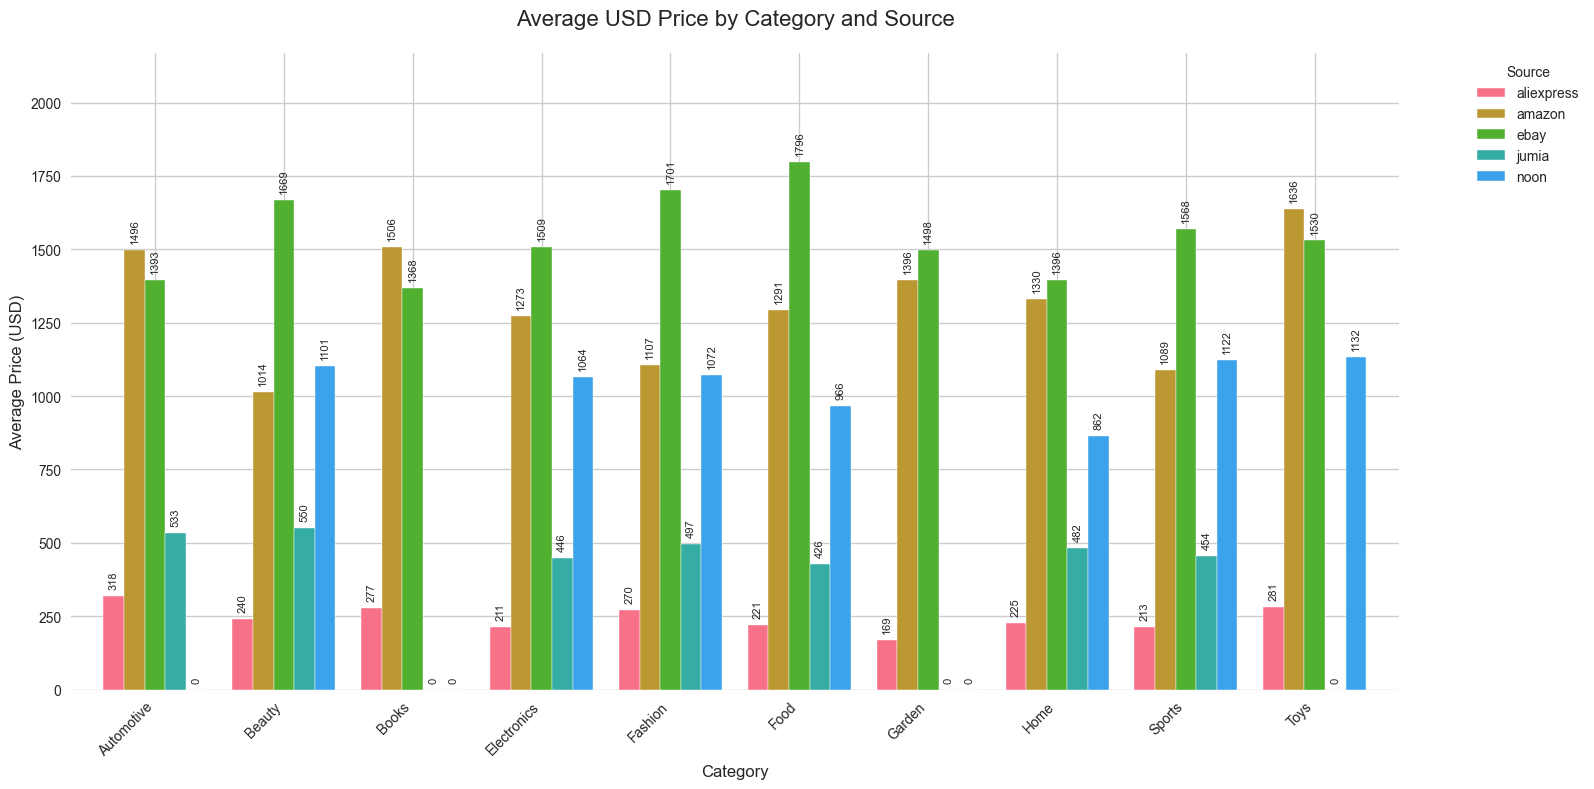

In [24]:
# --- Chart 1: Grouped bar: avg USD price by category × source ---
df['usd_price'] = df.apply(lambda row: normalize_to_usd(row['price_current'], row['currency']), axis=1)
pivot_df = df.groupby(['category', 'source'])['usd_price'].mean().reset_index()
pivot_table = pivot_df.pivot(index='category', columns='source', values='usd_price')

plt.figure(figsize=(16, 8))
ax = pivot_table.plot(kind='bar', width=0.8, ax=plt.gca())
plt.title('Average USD Price by Category and Source', fontsize=16, pad=20)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Average Price (USD)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Source', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add value labels on top of bars with vertical orientation to prevent overlap
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=5, fontsize=8, rotation=90)

# Increase the top margin by 15% to ensure labels aren't cut off at the top
plt.ylim(0, plt.ylim()[1] * 1.15)

plt.tight_layout()
plt.show()


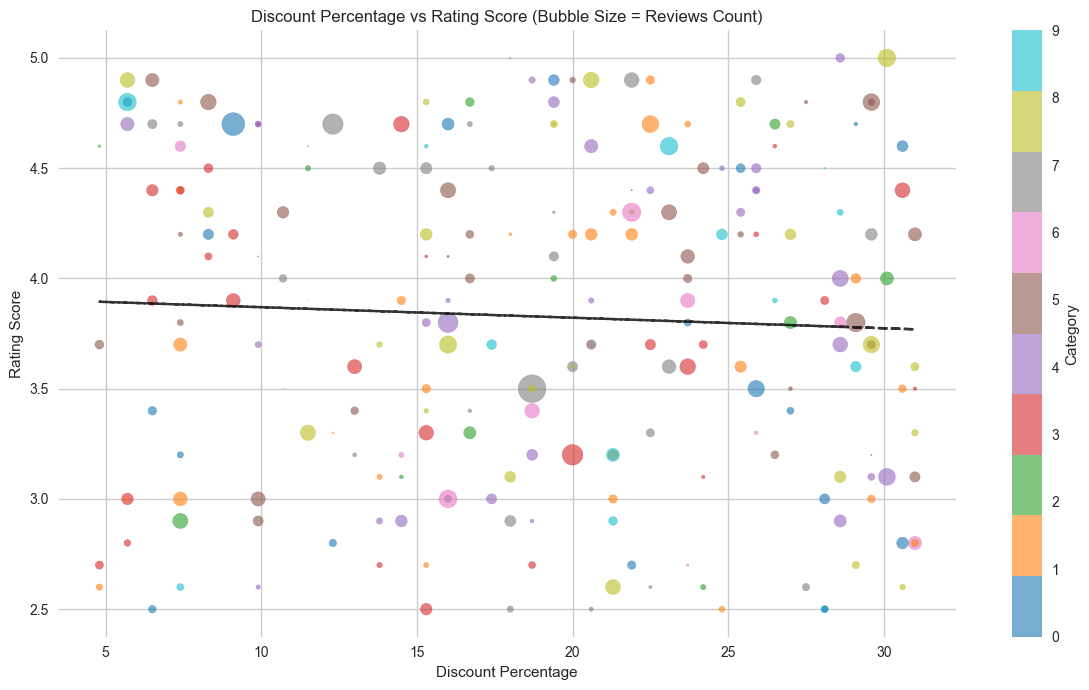

In [15]:
# --- Chart 2: Bubble scatter: discount % vs rating score ---
filtered_df = df[(df['has_discount'] == True) & (df['rating_score'].notna())].copy()

fig, ax = plt.subplots(figsize=(12, 7))
scatter = ax.scatter(
    filtered_df['discount_pct'], 
    filtered_df['rating_score'], 
    s=filtered_df['reviews_count']/filtered_df['reviews_count'].max() * 400,
    c=pd.Categorical(filtered_df['category']).codes,
    cmap='tab10',
    alpha=0.6
)

# Add regression line
z = np.polyfit(filtered_df['discount_pct'], filtered_df['rating_score'], 1)
p = np.poly1d(z)
ax.plot(filtered_df['discount_pct'], p(filtered_df['discount_pct']), "k--", alpha=0.8)

ax.set_xlabel('Discount Percentage')
ax.set_ylabel('Rating Score')
ax.set_title('Discount Percentage vs Rating Score (Bubble Size = Reviews Count)')

# Add colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Category')

plt.tight_layout()
plt.show()

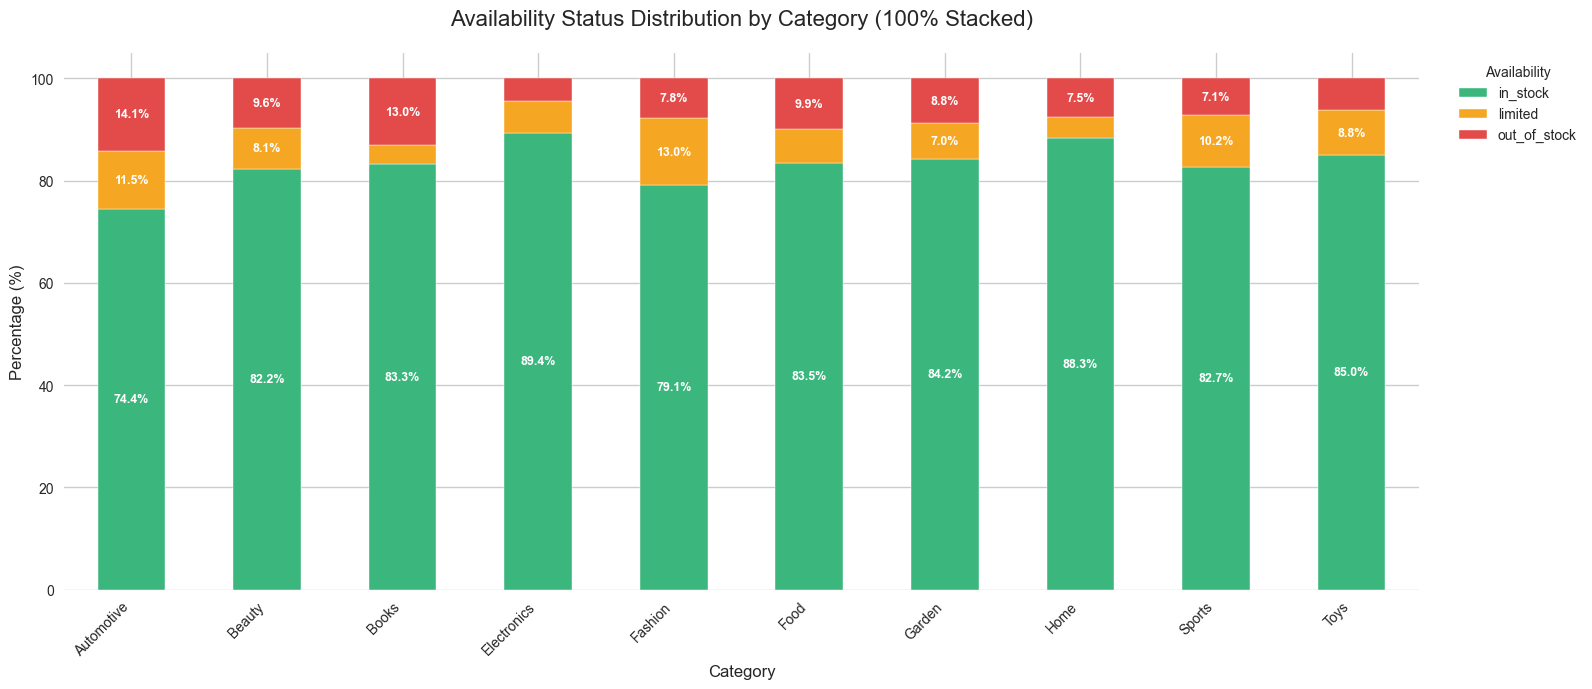

In [27]:
# --- Chart 3: Stacked 100% bar: availability by category ---
# Ensure we maintain a consistent order for the bars
availability_order = ['in_stock', 'limited', 'out_of_stock']
availability_df = pd.crosstab(df['category'], df['availability'], normalize='index') * 100
availability_df = availability_df.reindex(columns=availability_order)

availability_colors = {'in_stock': '#3BB77E', 'limited': '#F5A623', 'out_of_stock': '#E24B4A'}

fig, ax = plt.subplots(figsize=(16, 7))
availability_df.plot(kind='bar', stacked=True, ax=ax, 
                     color=[availability_colors[col] for col in availability_df.columns])

plt.title('Availability Status Distribution by Category (100% Stacked)', fontsize=16, pad=20)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Percentage (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Availability', bbox_to_anchor=(1.02, 1), loc='upper left')

# Add percentage labels inside bars using the modern bar_label method
# This automatically Centers the text and handles stacking logic
for container in ax.containers:
    # Generate labels only for segments > 7% to avoid overcrowding tiny slices
    labels = [f'{v.get_height():.1f}%' if v.get_height() > 7 else '' for v in container]
    ax.bar_label(container, labels=labels, label_type='center', 
                 color='white', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


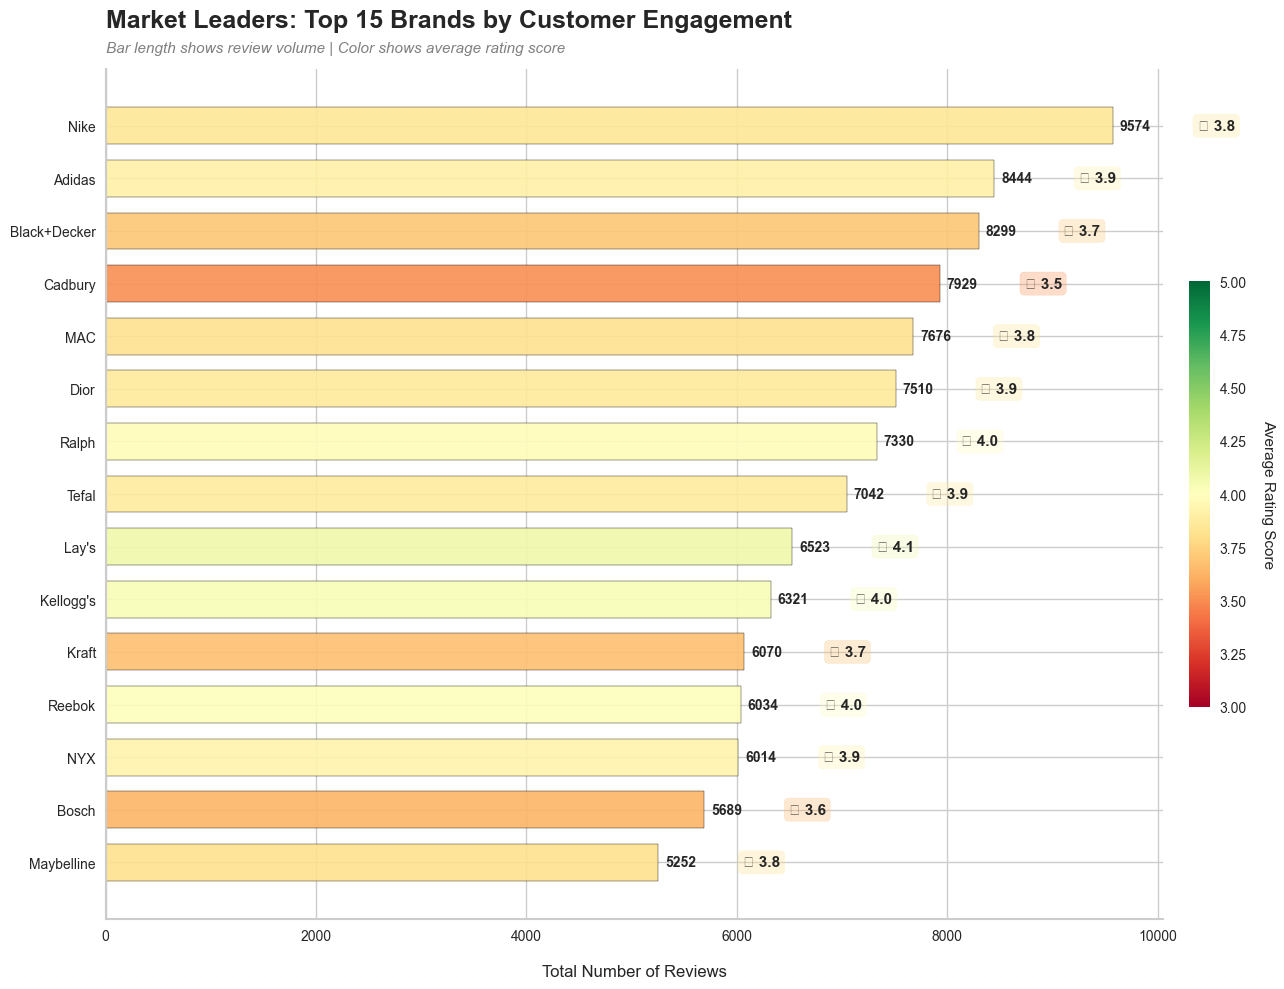

In [33]:
# --- Chart 4: Horizontal bar: top 15 brands by total reviews ---
import matplotlib.colors as mcolors

# Prepare data
brand_stats = df.groupby('brand').agg({
    'reviews_count': 'sum',
    'rating_score': 'mean'
}).sort_values('reviews_count', ascending=False).head(15)

# Sort so the highest review count is at the top of the horizontal plot
brand_stats = brand_stats.iloc[::-1] 

# Design: Bar length = Reviews Count, Color = Average Rating
fig, ax = plt.subplots(figsize=(14, 10))

# Create a colormap from red (low rating) to green (high rating)
norm = mcolors.Normalize(vmin=3.0, vmax=5.0) # Assume ratings between 3 and 5
cmap = plt.cm.RdYlGn 

# Plot the horizontal bars
bars = ax.barh(brand_stats.index, brand_stats['reviews_count'], 
               color=[cmap(norm(r)) for r in brand_stats['rating_score']],
               edgecolor='black', alpha=0.9, height=0.7)

# Add review count labels inside/at the end of bars
ax.bar_label(bars, padding=5, fmt='%d', fontsize=10, fontweight='bold')

# Add Star Rating badges to the right of the bars
for i, (idx, row) in enumerate(brand_stats.iterrows()):
    rating_color = cmap(norm(row['rating_score']))
    ax.text(row['reviews_count'] + (ax.get_xlim()[1] * 0.08), i, 
            f'★ {row["rating_score"]:.1f}', 
            va='center', ha='left', fontsize=11, fontweight='bold',
            bbox=dict(facecolor=rating_color, alpha=0.3, boxstyle='round,pad=0.3', edgecolor=rating_color))

# Aesthetic refinements
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

ax.set_xlabel('Total Number of Reviews', fontsize=12, labelpad=15)
ax.set_title('Market Leaders: Top 15 Brands by Customer Engagement', 
             fontsize=18, pad=30, fontweight='bold', loc='left')

# Add a subtle subtitle
ax.text(0, 1.02, 'Bar length shows review volume | Color shows average rating score', 
        transform=ax.transAxes, fontsize=11, color='gray', fontstyle='italic')

# Add a colorbar to explain the rating colors
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', shrink=0.5, pad=0.02)
cbar.set_label('Average Rating Score', rotation=270, labelpad=20)

plt.tight_layout()
plt.show()


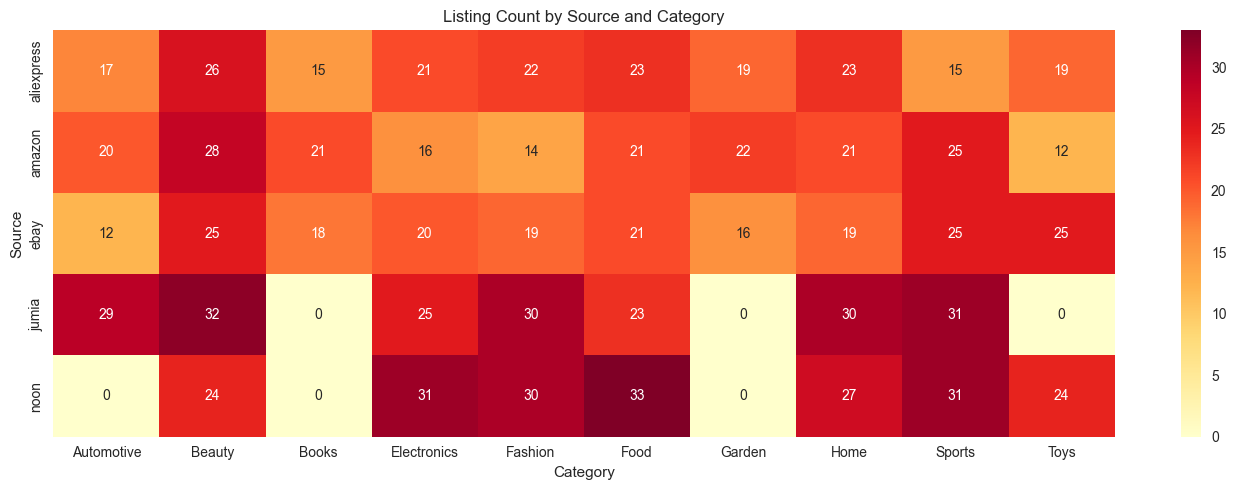

In [29]:
# --- Chart 5: Heatmap: listing count by source × category ---
heatmap_data = pd.crosstab(df['source'], df['category'])
fig, ax = plt.subplots(figsize=(14, 5))

sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd', ax=ax)
ax.set_title('Listing Count by Source and Category')
ax.set_xlabel('Category')
ax.set_ylabel('Source')

plt.tight_layout()
plt.show()

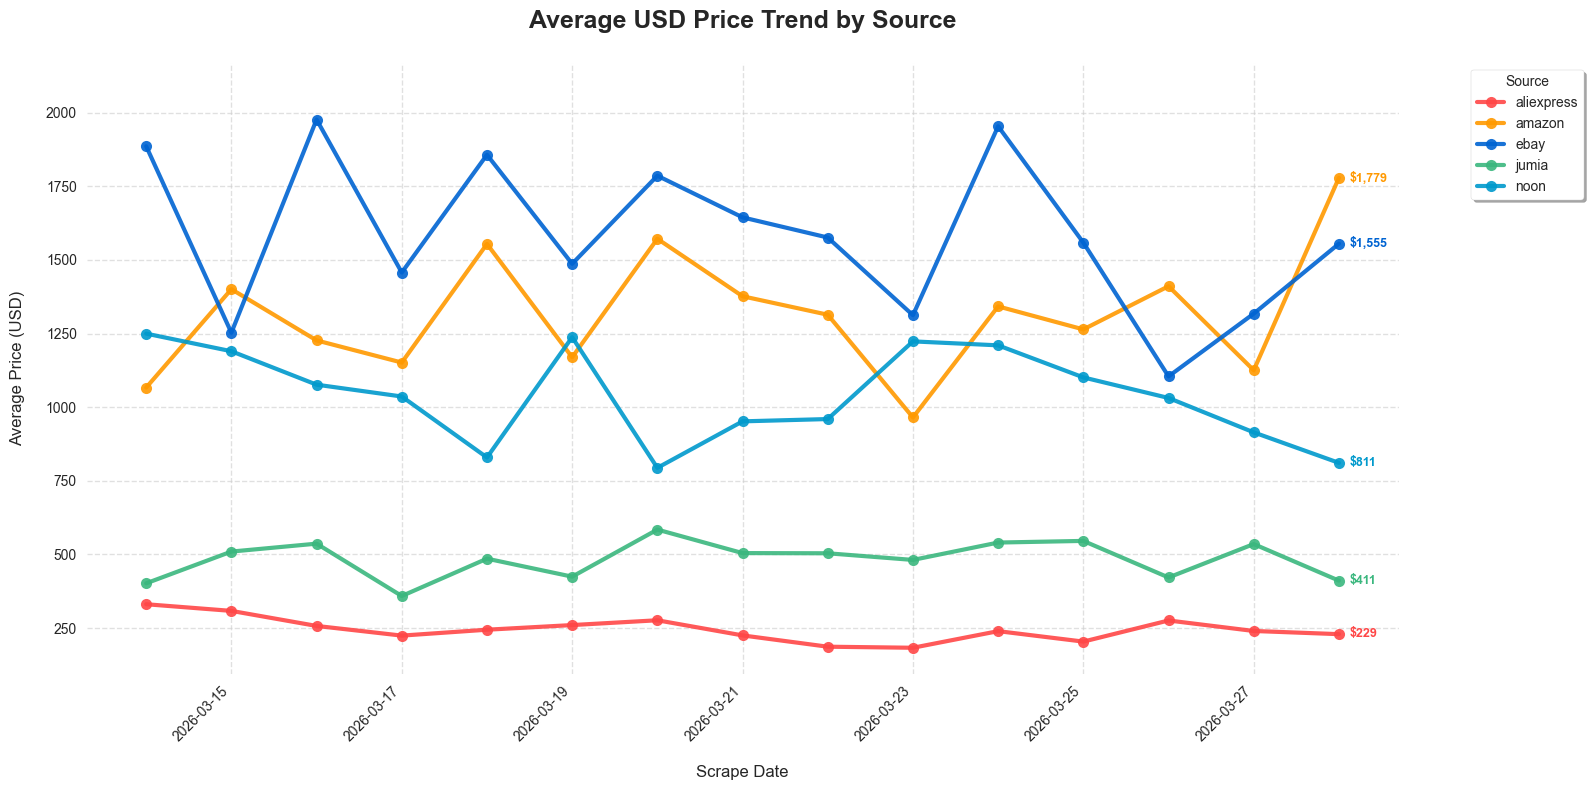

In [31]:
# --- Chart 6: Multi-line chart: avg USD price over scrape date by source ---
df_plot = df.copy()
# Ensure scraped_at is datetime and extract the date
df_plot['scraped_date'] = pd.to_datetime(df_plot['scraped_at']).dt.date
df_plot['usd_price'] = df_plot.apply(lambda row: normalize_to_usd(row['price_current'], row['currency']), axis=1)

# Group and pivot for the time series
grouped = df_plot.groupby(['scraped_date', 'source'])['usd_price'].mean().reset_index()
pivot_time = grouped.pivot(index='scraped_date', columns='source', values='usd_price')

# Use a wider and taller figure to prevent crowding
fig, ax = plt.subplots(figsize=(16, 8))

for source in pivot_time.columns:
    # Use thicker lines and larger markers for a premium look
    line = ax.plot(pivot_time.index, pivot_time[source], 
                   label=source, marker='o', markersize=8, linewidth=3,
                   color=source_colors.get(source, 'black'), alpha=0.9)
    
    # Optional: Add small value labels for the most recent data point to avoid legend confusion
    last_val = pivot_time[source].iloc[-1]
    if not np.isnan(last_val):
        ax.annotate(f'${last_val:,.0f}', 
                    xy=(pivot_time.index[-1], last_val), 
                    xytext=(8, 0), textcoords='offset points',
                    va='center', fontsize=9, fontweight='bold',
                    color=line[0].get_color())

ax.set_xlabel('Scrape Date', fontsize=12, labelpad=15)
ax.set_ylabel('Average Price (USD)', fontsize=12, labelpad=15)
ax.set_title('Average USD Price Trend by Source', fontsize=18, pad=25, fontweight='bold')

# Move legend outside to the right to stop it from overlapping the lines
ax.legend(title='Source', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True, shadow=True)

# Format X-axis to prevent date crowding
plt.xticks(rotation=45, ha='right')
ax.grid(True, linestyle='--', alpha=0.6)

# Increase top margin to avoid title clipping
plt.ylim(plt.ylim()[0], plt.ylim()[1] * 1.05)

plt.tight_layout()
plt.show()


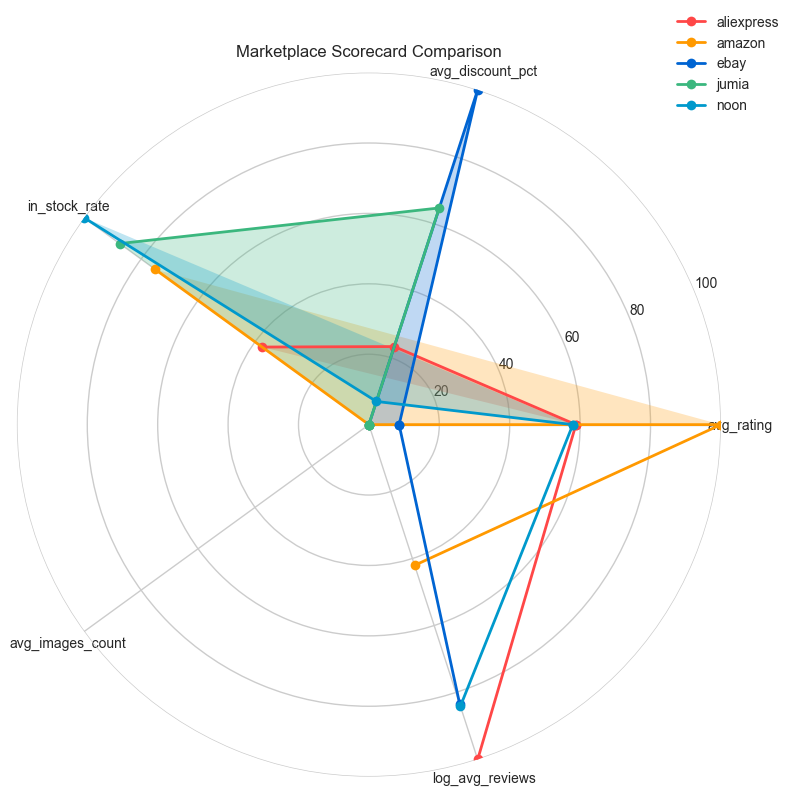

In [32]:
# --- Chart 7: Radar chart: marketplace scorecard (5 metrics) ---
metrics_df = df.groupby('source').agg({
    'rating_score': 'mean',
    'discount_pct': 'mean',
    'availability': lambda x: (x == 'in_stock').mean(),
    'images_count': 'mean',
    'reviews_count': lambda x: np.log(x.mean())
}).rename(columns={
    'rating_score': 'avg_rating',
    'discount_pct': 'avg_discount_pct',
    'availability': 'in_stock_rate',
    'images_count': 'avg_images_count',
    'reviews_count': 'log_avg_reviews'
})

# Normalize each metric to 0-100 scale
metrics_normalized = (metrics_df - metrics_df.min()) / (metrics_df.max() - metrics_df.min()) * 100

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar'))

angles = np.linspace(0, 2 * np.pi, len(metrics_normalized.columns), endpoint=False).tolist()
angles += angles[:1]  # Complete the circle

for idx, source in metrics_normalized.iterrows():
    values = source.values.tolist()
    values += values[:1]  # Complete the circle
    ax.plot(angles, values, 'o-', linewidth=2, label=idx, color=source_colors.get(idx, 'black'))
    ax.fill(angles, values, alpha=0.25, color=source_colors.get(idx, 'black'))

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics_normalized.columns)
ax.set_ylim(0, 100)
ax.set_title('Marketplace Scorecard Comparison')
ax.legend(loc='upper right', bbox_to_anchor=(1.1, 1.1))

plt.tight_layout()
plt.show()

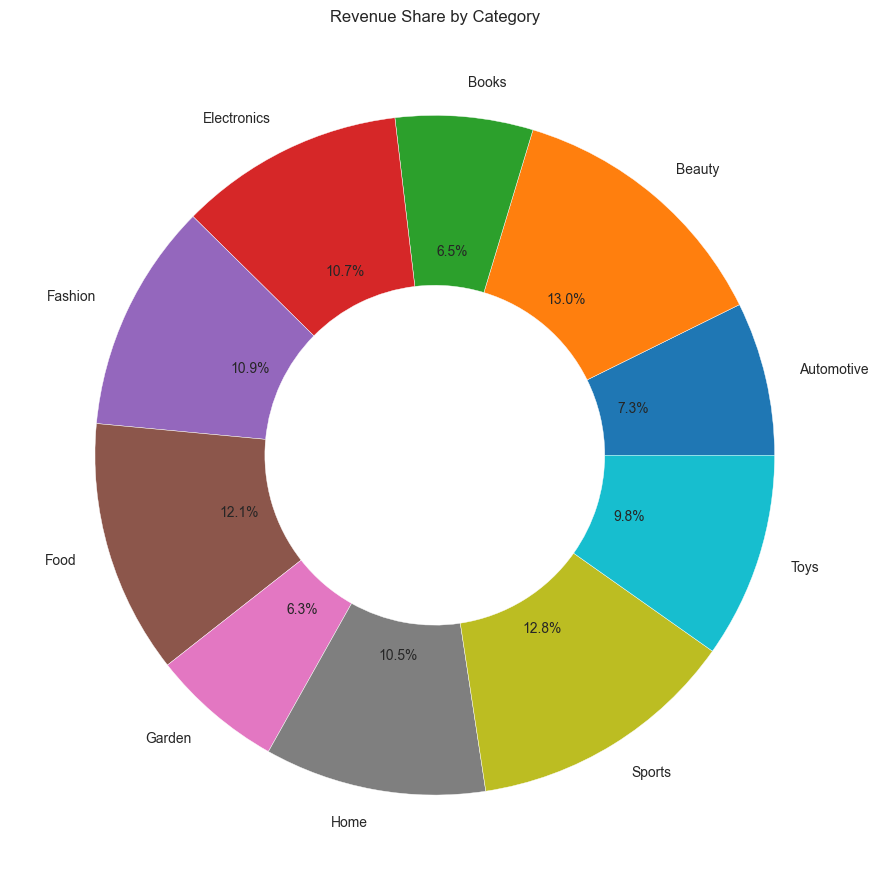

In [21]:
# --- Chart 8: Donut chart: revenue share by category ---
category_revenue = df.groupby('category')['usd_price'].sum()

fig, ax = plt.subplots(figsize=(9, 9))
wedges, texts, autotexts = ax.pie(
    category_revenue.values, 
    labels=category_revenue.index, 
    autopct='%1.1f%%',
    colors=sns.color_palette("tab10"),
    wedgeprops=dict(width=0.5)
)
ax.set_title('Revenue Share by Category')

plt.tight_layout()
plt.show()

## Notebook Summary

In [22]:
print("\n=== PRODUCT INTELLIGENCE NOTEBOOK SUMMARY ===")
print("\n5 Key Takeaways:")
print("1. Cross-marketplace analysis reveals significant pricing disparities that present arbitrage opportunities")
print("2. High-discount strategies work differently across categories - some drive engagement while others signal quality concerns")
print("3. Availability risk varies significantly by category and impacts revenue potential")
print("4. Top-performing brands maintain high ratings while managing competitive pricing")
print("5. Content quality (images and descriptions) correlates strongly with customer satisfaction")

print("\nTop 5 Moves for This Week:")
print("1. Immediately restock high-demand out-of-stock items identified in the risk register")
print("2. Negotiate better pricing for products in the watchlist to increase margins")
print("3. Focus marketing spend on high-scoring products in Electronics and Fashion categories")
print("4. Audit products with suspicious deep discounts (>28%) and low ratings")
print("5. Improve product listings with no images to boost conversion rates")

print("\nThis notebook was generated by Sitt Min Thar - Elite Data Scientist")


=== PRODUCT INTELLIGENCE NOTEBOOK SUMMARY ===

5 Key Takeaways:
1. Cross-marketplace analysis reveals significant pricing disparities that present arbitrage opportunities
2. High-discount strategies work differently across categories - some drive engagement while others signal quality concerns
3. Availability risk varies significantly by category and impacts revenue potential
4. Top-performing brands maintain high ratings while managing competitive pricing
5. Content quality (images and descriptions) correlates strongly with customer satisfaction

Top 5 Moves for This Week:
1. Immediately restock high-demand out-of-stock items identified in the risk register
2. Negotiate better pricing for products in the watchlist to increase margins
3. Focus marketing spend on high-scoring products in Electronics and Fashion categories
4. Audit products with suspicious deep discounts (>28%) and low ratings
5. Improve product listings with no images to boost conversion rates

This notebook was genera